<h1>Train — DenseNet-121</h1>

Trains and evaluates DenseNet-121 using the tuned hyperparameters from `ARCH_HYPERPARAMS["densenet121"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): CapeFlats
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 828 | Val: 203 | Test: 1476


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["densenet121"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"DenseNet-121: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

DenseNet-121: micro batch = 16, accumulation steps = 2 (effective batch size ≈ 32, tuned value = 32)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with DenseNet-121)
# ---------------------------------------------------------
model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
in_f = model.classifier.in_features
model.classifier = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[DenseNet-121] Using gradient accumulation: 2 micro-batches per optimizer step (effective batch size ≈ micro_batch x 2).


[DenseNet-121] Epoch   1/100 | LR: 1.00e-04 | train loss 1.1988 acc 0.448 | val loss 0.8860 acc 0.512 *


[DenseNet-121] Epoch   2/100 | LR: 1.00e-04 | train loss 0.7497 acc 0.678 | val loss 0.5273 acc 0.793 *


[DenseNet-121] Epoch   3/100 | LR: 1.00e-04 | train loss 0.4371 acc 0.791 | val loss 0.4837 acc 0.813 *


[DenseNet-121] Epoch   4/100 | LR: 1.00e-04 | train loss 0.3782 acc 0.818 | val loss 0.5708 acc 0.803


...

[DenseNet-121] Epoch  13/100 | LR: 1.00e-04 | train loss 0.1190 acc 0.935 | val loss 0.4461 acc 0.842


[DenseNet-121] Epoch  14/100 | LR: 1.00e-04 | train loss 0.1381 acc 0.937 | val loss 0.6040 acc 0.828


[DenseNet-121] Epoch  15/100 | LR: 1.00e-05 | train loss 0.1053 acc 0.958 | val loss 0.5177 acc 0.833


[DenseNet-121] Epoch  16/100 | LR: 1.00e-05 | train loss 0.0610 acc 0.970 | val loss 0.4944 acc 0.867


[DenseNet-121] Epoch  17/100 | LR: 1.00e-05 | train loss 0.0567 acc 0.972 | val loss 0.4925 acc 0.862

[DenseNet-121] No val loss improvement for 10 epochs — stopping early at epoch 17.

[DenseNet-121] Restored best checkpoint (val loss = 0.3666)


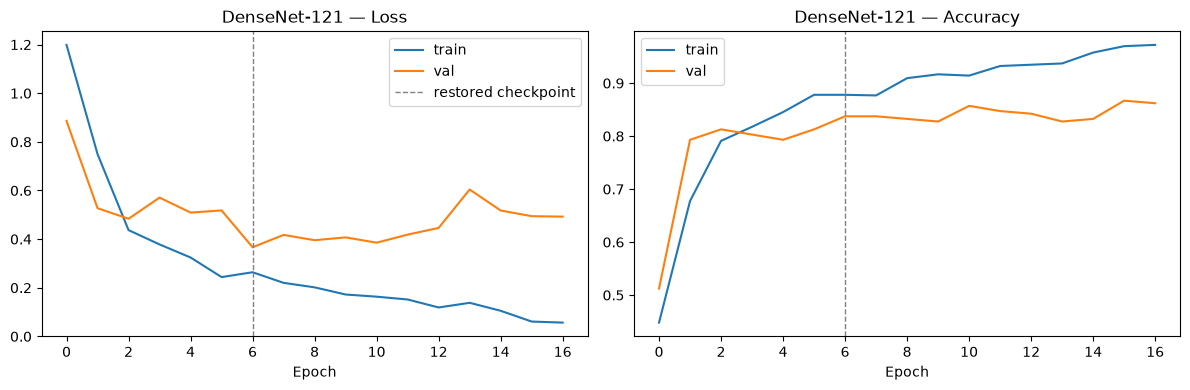

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "DenseNet-121", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "DenseNet-121")

## Evaluate on the test set

[DenseNet-121] Test accuracy: 0.596


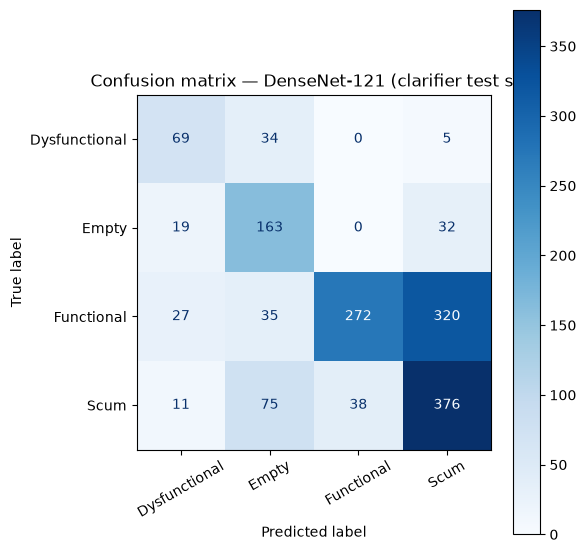

               precision    recall  f1-score   support

Dysfunctional      0.548     0.639     0.590       108
        Empty      0.531     0.762     0.626       214
   Functional      0.877     0.416     0.564       654
         Scum      0.513     0.752     0.610       500

     accuracy                          0.596      1476
    macro avg      0.617     0.642     0.597      1476
 weighted avg      0.680     0.596     0.591      1476



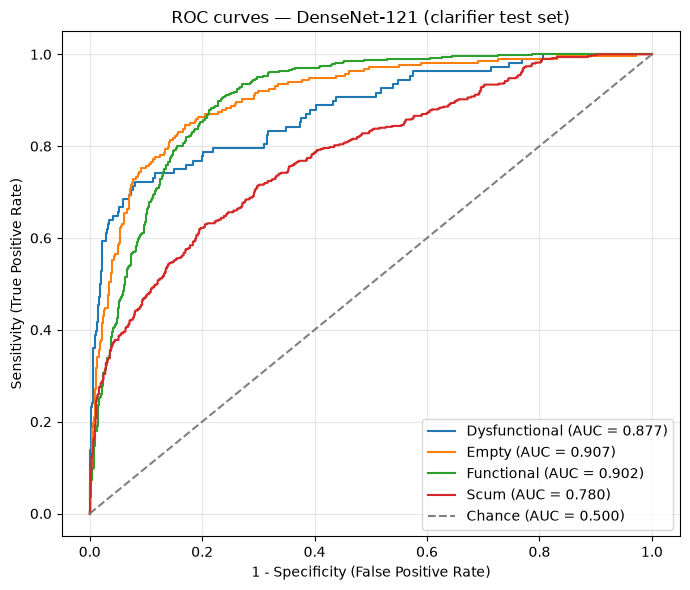

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.877
  Empty          : 0.907
  Functional     : 0.902
  Scum           : 0.780

Mean AUC (over 4/4 classes with test examples): 0.867


(np.float64(0.5962059620596206),
 {'Dysfunctional': 0.8767394953432966,
  'Empty': 0.9071863382555505,
  'Functional': 0.9020420842727145,
  'Scum': 0.780218237704918})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "DenseNet-121", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("DenseNet-121", "densenet121")

Saved results to ../results/results_clarifier_densenet121_CapeFlats.pkl
Saved model weights to ../models/clarifier_densenet121_cnn.pt
